<a href="https://colab.research.google.com/github/dzidz1/Freeuni_ML_Walmart_Sales_Forecasting/blob/main/model_experiment_TimesFm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install

In [1]:
!pip -q install -U "timesfm[torch]" kaggle mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/

# Imports + Config

In [15]:
import os
import json
import random
import warnings
from pathlib import Path
from zipfile import ZipFile

import mlflow
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
QUICK_RUN = False

MODEL_NAME = "TimesFM"
EXPERIMENT_NAME = "TimesFM_Training"

VALIDATION_WEEKS = 13
CONTEXT_LENGTH = 104
MIN_CONTEXT_POINTS = 32
HORIZON = VALIDATION_WEEKS
BATCH_SIZE = 32

TIMESFM_CHECKPOINT = "google/timesfm-2.5-200m-pytorch"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


# Paths + Kaggle Credentials

In [16]:
from google.colab import drive, userdata

drive.mount("/content/drive")

WORK_DIR = Path("/content/drive/MyDrive/walmart_final_project")
DATA_DIR = WORK_DIR / "data"
ARTIFACT_DIR = WORK_DIR / "artifacts" / MODEL_NAME.lower()

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

kaggle_username = userdata.get("KAGGLE_USERNAME")
kaggle_token = userdata.get("KAGGLE_API_TOKEN")

if kaggle_username is None or kaggle_token is None:
    raise ValueError("Colab Secrets-ში KAGGLE_USERNAME ან KAGGLE_API_TOKEN არ ჩანს.")

os.environ["KAGGLE_USERNAME"] = kaggle_username
os.environ["KAGGLE_KEY"] = kaggle_token

print("DATA_DIR:", DATA_DIR)
print("ARTIFACT_DIR:", ARTIFACT_DIR)
print("Kaggle credentials loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR: /content/drive/MyDrive/walmart_final_project/data
ARTIFACT_DIR: /content/drive/MyDrive/walmart_final_project/artifacts/timesfm
Kaggle credentials loaded.


# Download + Load Data

In [17]:
competition = "walmart-recruiting-store-sales-forecasting"

if not (DATA_DIR / "train.csv").exists():
    !kaggle competitions download -c walmart-recruiting-store-sales-forecasting -p "{DATA_DIR}"

    for zip_path in DATA_DIR.glob("*.zip"):
        with ZipFile(zip_path, "r") as zf:
            zf.extractall(DATA_DIR)

train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
features = pd.read_csv(DATA_DIR / "features.csv", parse_dates=["Date"])
stores = pd.read_csv(DATA_DIR / "stores.csv")

print(train.shape, test.shape, features.shape, stores.shape)
train.head()

(421570, 5) (115064, 4) (8190, 12) (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


# Preprocessing Functions

In [18]:
def make_unique_id(df):
    return df["Store"].astype(str) + "_" + df["Dept"].astype(str)


def walmart_wmae(y_true, y_pred, is_holiday):
    weights = np.where(pd.Series(is_holiday).astype(bool).to_numpy(), 5, 1)
    errors = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    return float(np.sum(weights * errors) / np.sum(weights))


def prepare_timesfm_frame(train_df):
    df = train_df.copy()
    df["unique_id"] = make_unique_id(df)

    ids = df[["unique_id"]].drop_duplicates()
    dates = pd.DataFrame({
        "ds": pd.date_range(df["Date"].min(), df["Date"].max(), freq="W-FRI")
    })

    grid = ids.merge(dates, how="cross")

    out = grid.merge(
        df[["unique_id", "Date", "Weekly_Sales", "IsHoliday"]],
        left_on=["unique_id", "ds"],
        right_on=["unique_id", "Date"],
        how="left",
    )

    out["y"] = out["Weekly_Sales"].fillna(0).astype(float)
    out["IsHoliday"] = out["IsHoliday"].fillna(False).astype(bool)

    return (
        out[["unique_id", "ds", "y", "IsHoliday"]]
        .sort_values(["unique_id", "ds"])
        .reset_index(drop=True)
    )

# Build Dataset + Date-wise Split

In [19]:
timesfm_full = prepare_timesfm_frame(train)

if QUICK_RUN:
    top_ids = (
        train.assign(unique_id=make_unique_id(train))
        .groupby("unique_id")["Weekly_Sales"]
        .sum()
        .nlargest(120)
        .index
    )
    timesfm_full = timesfm_full[timesfm_full["unique_id"].isin(top_ids)].copy()

validation_start = timesfm_full["ds"].max() - pd.Timedelta(weeks=VALIDATION_WEEKS - 1)

train_part = timesfm_full[timesfm_full["ds"] < validation_start].copy()
valid_part = timesfm_full[timesfm_full["ds"] >= validation_start].copy()

print("series:", timesfm_full["unique_id"].nunique())
print("train_part:", train_part.shape)
print("valid_part:", valid_part.shape)
print("validation start:", validation_start.date())

valid_part.head()

series: 3331
train_part: (433030, 4)
valid_part: (43303, 4)
validation start: 2012-08-03


,unique_id,ds,y,IsHoliday
130,10_1,2012-08-03,26390.26,False
131,10_1,2012-08-10,26320.29,False
132,10_1,2012-08-17,26752.40,False
133,10_1,2012-08-24,26804.84,False
134,10_1,2012-08-31,26083.28,False


# MLflow + DagsHub

In [20]:
from google.colab import userdata

DAGSHUB_USERNAME = "mgior23"
DAGSHUB_REPO_OWNER = "adzid23"
DAGSHUB_REPO_NAME = "Freeuni_ML_Walmart_Sales_Forecasting"

dagshub_token = userdata.get("DAGSHUB_TOKEN")

if dagshub_token is None:
    raise ValueError("Colab Secrets-ში DAGSHUB_TOKEN არ ჩანს.")

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = dagshub_token

mlflow.set_tracking_uri(
    f"https://dagshub.com/{DAGSHUB_REPO_OWNER}/{DAGSHUB_REPO_NAME}.mlflow"
)

if mlflow.active_run():
    mlflow.end_run()

mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", EXPERIMENT_NAME)

MLflow tracking URI: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow
Experiment: TimesFM_Training


# Log Preprocessing Run

In [21]:
with mlflow.start_run(run_name="TimesFM_Preprocessing"):
    mlflow.log_params({
        "model_family": "Foundation Model",
        "architecture": "TimesFM",
        "checkpoint": TIMESFM_CHECKPOINT,
        "forecasting_mode": "zero_shot",
        "quick_run": QUICK_RUN,
        "validation_weeks": VALIDATION_WEEKS,
        "context_length": CONTEXT_LENGTH,
        "missing_week_strategy": "fill_missing_sales_with_zero",
    })

    mlflow.log_metrics({
        "n_series": timesfm_full["unique_id"].nunique(),
        "n_rows": len(timesfm_full),
        "n_train_rows": len(train_part),
        "n_valid_rows": len(valid_part),
    })

print("TimesFM preprocessing run logged.")

🏃 View run TimesFM_Preprocessing at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/8/runs/60b6367164e244c08973e75cb7b2df9d
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/8
TimesFM preprocessing run logged.


# Load TimesFM 2.5

In [22]:
import timesfm

torch.set_float32_matmul_precision("high")

timesfm_model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    TIMESFM_CHECKPOINT
)

timesfm_model.compile(
    timesfm.ForecastConfig(
        max_context=CONTEXT_LENGTH,
        max_horizon=HORIZON,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
        per_core_batch_size=BATCH_SIZE,
    )
)

print("TimesFM model loaded:", TIMESFM_CHECKPOINT)

TimesFM model loaded: google/timesfm-2.5-200m-pytorch


# Prepare Contexts

In [23]:
series_ids = []
contexts = []

for unique_id, group in train_part.groupby("unique_id", sort=False):
    values = group.sort_values("ds")["y"].to_numpy(dtype=np.float32)

    if len(values) >= MIN_CONTEXT_POINTS:
        series_ids.append(unique_id)
        contexts.append(values[-CONTEXT_LENGTH:])

print("usable series:", len(series_ids))
print("example context length:", len(contexts[0]))

usable series: 3331
example context length: 104


# Zero-shot Forecast + MLflow Run

In [24]:
def forecast_in_chunks(model, inputs, horizon, chunk_size):
    point_parts = []
    quantile_parts = []

    for start in range(0, len(inputs), chunk_size):
        batch_inputs = inputs[start:start + chunk_size]
        point_fc, quantile_fc = model.forecast(
            horizon=horizon,
            inputs=batch_inputs,
        )
        point_parts.append(point_fc)
        quantile_parts.append(quantile_fc)

    return np.vstack(point_parts), np.vstack(quantile_parts)


run_suffix = "Quick" if QUICK_RUN else "Full"
run_name = f"TimesFM_ZeroShot_Context{CONTEXT_LENGTH}_{run_suffix}"

with mlflow.start_run(run_name=run_name) as run:
    mlflow.log_params({
        "run_type": "zero_shot_forecasting",
        "model_family": "Foundation Model",
        "architecture": "TimesFM",
        "checkpoint": TIMESFM_CHECKPOINT,
        "quick_run": QUICK_RUN,
        "context_length": CONTEXT_LENGTH,
        "horizon": HORIZON,
        "batch_size": BATCH_SIZE,
        "n_series": len(series_ids),
        "trained_on_walmart": False,
    })

    point_fc, quantile_fc = forecast_in_chunks(
        timesfm_model,
        contexts,
        horizon=HORIZON,
        chunk_size=BATCH_SIZE,
    )

    valid_dates = sorted(valid_part["ds"].unique())

    pred_rows = []
    for i, unique_id in enumerate(series_ids):
        for h, ds in enumerate(valid_dates):
            pred_rows.append({
                "unique_id": unique_id,
                "ds": ds,
                "TimesFM": max(0.0, float(point_fc[i, h])),
                "q10": max(0.0, float(quantile_fc[i, h, 1])),
                "q90": max(0.0, float(quantile_fc[i, h, 9])),
            })

    pred_df = pd.DataFrame(pred_rows)

    eval_df = valid_part.merge(pred_df, on=["unique_id", "ds"], how="inner")

    validation_wmae = walmart_wmae(
        eval_df["y"],
        eval_df["TimesFM"],
        eval_df["IsHoliday"],
    )

    mlflow.log_metric("validation_wmae", validation_wmae)

    pred_path = ARTIFACT_DIR / f"{run_name}_validation_predictions.csv"
    eval_df.to_csv(pred_path, index=False)
    mlflow.log_artifact(str(pred_path), artifact_path="validation")

    config = {
        "checkpoint": TIMESFM_CHECKPOINT,
        "context_length": CONTEXT_LENGTH,
        "horizon": HORIZON,
        "batch_size": BATCH_SIZE,
        "forecasting_mode": "zero_shot",
        "note": "TimesFM is pretrained; no Walmart-specific training was performed.",
    }
    mlflow.log_dict(config, "timesfm_config.json")

    run_id = run.info.run_id

print("Validation WMAE:", validation_wmae)
print("Run ID:", run_id)
eval_df.head()

🏃 View run TimesFM_ZeroShot_Context104_Full at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/8/runs/e19d799e9477402bb0a80af900d1a329
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/8
Validation WMAE: 1179.4126091705114
Run ID: e19d799e9477402bb0a80af900d1a329


,unique_id,ds,y,IsHoliday,TimesFM,q10,q90
0,10_1,2012-08-03,26390.26,False,26899.398438,25461.527344,32609.552734
1,10_1,2012-08-10,26320.29,False,27032.976562,25368.542969,33294.261719
2,10_1,2012-08-17,26752.40,False,27130.375000,25382.328125,34965.828125
3,10_1,2012-08-24,26804.84,False,26893.375000,24475.443359,36419.953125
4,10_1,2012-08-31,26083.28,False,27331.601562,23719.269531,38546.820312


# Visualization

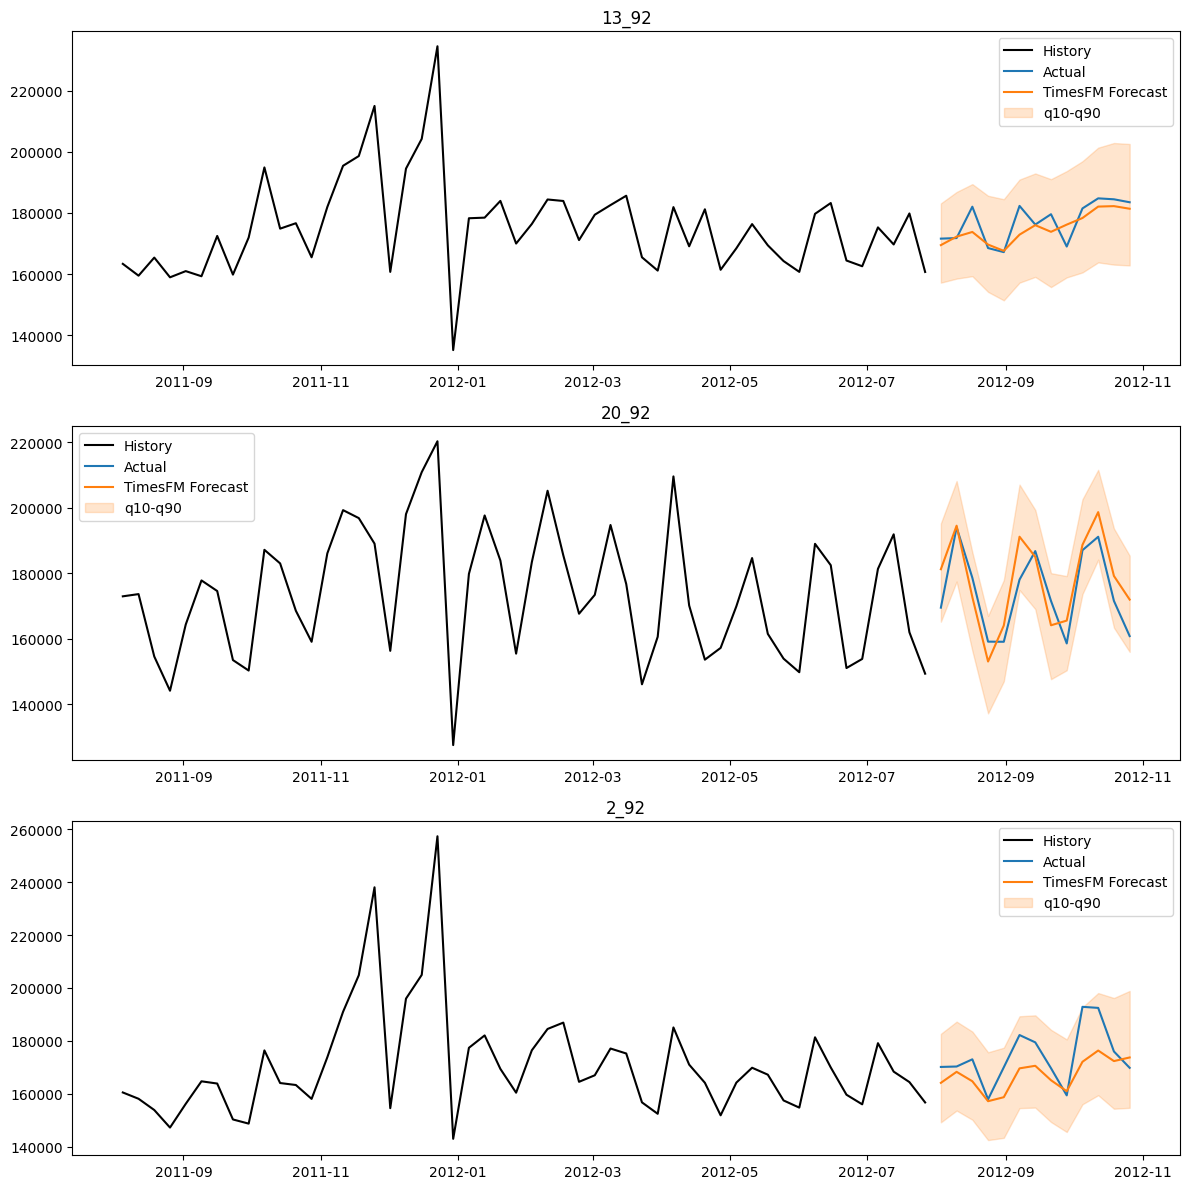

🏃 View run TimesFM_Validation_Visualization at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/8/runs/a52f92920e5b41c39c8f10dd129ea72a
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/8
Validation plot logged.


In [25]:
plot_ids = eval_df.groupby("unique_id")["y"].sum().nlargest(3).index.tolist()

fig, axes = plt.subplots(len(plot_ids), 1, figsize=(12, 4 * len(plot_ids)), sharex=False)

if len(plot_ids) == 1:
    axes = [axes]

for ax, unique_id in zip(axes, plot_ids):
    hist = train_part[train_part["unique_id"] == unique_id].tail(52)
    pred = eval_df[eval_df["unique_id"] == unique_id].sort_values("ds")

    ax.plot(hist["ds"], hist["y"], label="History", color="black")
    ax.plot(pred["ds"], pred["y"], label="Actual", color="tab:blue")
    ax.plot(pred["ds"], pred["TimesFM"], label="TimesFM Forecast", color="tab:orange")
    ax.fill_between(pred["ds"], pred["q10"], pred["q90"], color="tab:orange", alpha=0.2, label="q10-q90")
    ax.set_title(unique_id)
    ax.legend()

plt.tight_layout()

plot_path = ARTIFACT_DIR / f"{run_name}_validation_plot.png"
plt.savefig(plot_path, dpi=150)
plt.show()

with mlflow.start_run(run_name="TimesFM_Validation_Visualization"):
    mlflow.log_param("source_run_id", run_id)
    mlflow.log_metric("validation_wmae", validation_wmae)
    mlflow.log_artifact(str(plot_path), artifact_path="plots")

print("Validation plot logged.")

# Comparison

In [26]:
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.validation_wmae ASC"],
)

runs_df = runs_df[runs_df["metrics.validation_wmae"].notna()].copy()

comparison_cols = [
    "tags.mlflow.runName",
    "metrics.validation_wmae",
    "params.run_type",
    "params.quick_run",
    "params.context_length",
    "params.horizon",
    "params.batch_size",
    "params.n_series",
    "params.checkpoint",
]

available_cols = [col for col in comparison_cols if col in runs_df.columns]

timesfm_comparison = runs_df[available_cols].copy()
timesfm_comparison

,tags.mlflow.runName,metrics.validation_wmae,params.run_type,params.quick_run,params.context_length,params.horizon,params.batch_size,params.n_series,params.checkpoint
0,TimesFM_Validation_Visualization,1179.412609,None,None,None,None,None,None,None
1,TimesFM_ZeroShot_Context104_Full,1179.412609,zero_shot_forecasting,False,104,13,32,3331,google/timesfm-2.5-200m-pytorch
2,TimesFM_Validation_Visualization,5137.104063,None,None,None,None,None,None,None
3,TimesFM_ZeroShot_Context104_Quick,5137.104063,zero_shot_forecasting,True,104,13,32,120,google/timesfm-2.5-200m-pytorch
